# Replication of Table 1 & Table 2
## Walk-Forward Out-of-Sample Portfolio Performance

This notebook replicates **Table 1** (walk-forward performance metrics) and **Table 2** (aggregated OOS Sharpe ratios) from the QHRP paper.

**Strategies compared:**
- Quantum HRP
- Classical HRP
- Kernel-based HRP
- Markowitz (inverse-variance)
- Equal Weights (1/N)

In [51]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, skew, kurtosis
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys
import time as _time
import pickle
from joblib import Parallel, delayed

# Add RiskLabAI to path
sys.path.insert(0, os.path.abspath("../../repos/RiskLabAI.py"))
from RiskLabAI.optimization import hrp, recursive_bisection

# Add local quantum_hrp module
sys.path.insert(0, os.path.abspath("../qhrp_figure3_4"))
from src.quantum_hrp import (
    compute_financial_features,
    average_density_matrix,
    compute_distance_matrix,
    quantum_ordering,
    classical_hrp_ordering,
    frobenius_distance,
    sharpe_ratio,
    probabilistic_sharpe_ratio,
    min_track_record_length,
    markowitz_weights,
    equal_weights,
    quasi_diagonal,
    distance_corr,
    gaussian_mmd_distance,
    compute_kernel_distance_matrix,
    kernel_based_hrp_ordering,
)

print("All imports OK")

All imports OK


In [52]:
# ── Configuration ─────────────────────────────────────────────────────────
DATA_DIR = os.path.abspath("../../data")
OUT_DIR  = os.path.abspath("../../latex/img")
CACHE_DIR = os.path.abspath("./cache")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(CACHE_DIR, exist_ok=True)

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  QUICK TEST MODE: set to True to run only a few windows first,        │
# │  verify correctness, then set to False for the full run.               │
# └─────────────────────────────────────────────────────────────────────────┘
QUICK_TEST      = True     # ← Set to False for full run
QUICK_N_WINDOWS = 10       # number of windows in quick-test mode

# Walk-forward parameters
TRAINING_WINDOW = 756   # ~3 years of trading days
TEST_WINDOW     = 21    # ~1 month
ALPHA           = 2.0   # quantum feature map parameter
P_FEATURES      = 6     # number of features (6 financial features per timestep)
RF              = 0.01  # annual risk-free rate
TARGET_SR       = 0     # benchmark Sharpe for PSR
CONFIDENCE      = 0.95  # confidence for MinTRL

# Parallelisation
N_JOBS = -1  # use all CPU cores (-1), or set to a fixed number

print(f"Training window: {TRAINING_WINDOW} days")
print(f"Test window:     {TEST_WINDOW} days")
print(f"Features:        P={P_FEATURES}")
if QUICK_TEST:
    print(f"Quick test:      ON ({QUICK_N_WINDOWS} windows)")
else:
    print(f"Quick test:      OFF (full run)")
print(f"Parallelisation: {N_JOBS} cores")

Training window: 756 days
Test window:     21 days
Features:        P=6
Quick test:      ON (10 windows)
Parallelisation: -1 cores


In [53]:
# ── Load data (per-window NaN handling — keeps all assets) ────────────────
prices = pd.read_parquet(os.path.join(DATA_DIR, "prices.parquet"))
print(f"Prices loaded: {prices.shape[0]} days, {prices.shape[1]} assets")
print(f"Date range: {prices.index.min()} → {prices.index.max()}")

# Compute returns — keep ALL columns, don't drop NaN globally
returns_all = prices.pct_change().dropna(how="all")    # drop rows where everything is NaN
returns_all = returns_all.apply(pd.to_numeric, errors="coerce")

# Remove assets that are entirely NaN
returns_all = returns_all.dropna(axis=1, how="all")

# Remove assets with near-zero variance (using only non-NaN values)
std = returns_all.std()
returns_all = returns_all.loc[:, std > 1e-8]

R_full = returns_all.values       # (T_total, N_all) — may contain NaN
T_total = R_full.shape[0]
N_all   = R_full.shape[1]
col_names = returns_all.columns.tolist()

print(f"Returns (with NaN): T={T_total}, N_all={N_all}")
print(f"Per-window asset selection will drop columns with NaN in each window.")

Prices loaded: 6202 days, 169 assets
Date range: 2005-01-03 00:00:00 → 2024-12-31 00:00:00
Returns (with NaN): T=6201, N_all=169
Per-window asset selection will drop columns with NaN in each window.


In [54]:
# ── Helpers ───────────────────────────────────────────────────────────────
import pickle
from joblib import Parallel, delayed

def hrp_recursive_bisection(cov, sorted_items):
    """Compute HRP weights via recursive bisection."""
    cov_df = pd.DataFrame(cov)
    return recursive_bisection(cov_df, sorted_items)

def compute_density_for_asset(feat, alpha):
    """Compute average density matrix for one asset (parallelisable)."""
    return average_density_matrix(feat, alpha)

def compute_all_densities_parallel(training_features, alpha, n_jobs):
    """Compute density matrices for all N assets in parallel."""
    rho_list = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(compute_density_for_asset)(feat, alpha)
        for feat in training_features
    )
    return rho_list

def save_checkpoint(results, w, path):
    """Save partial results to disk."""
    with open(path, "wb") as f:
        pickle.dump({"results": results, "last_window": w}, f)

def load_checkpoint(path):
    """Load partial results from disk."""
    if os.path.exists(path):
        with open(path, "rb") as f:
            data = pickle.load(f)
        return data["results"], data["last_window"]
    return None, -1

print("Helpers defined.")

Helpers defined.


In [55]:
# ── Walk-Forward Out-of-Sample Analysis (per-window asset selection) ─────
CHECKPOINT_PATH = os.path.join(CACHE_DIR, "walkforward_checkpoint.pkl")

num_windows_total = (T_total - TRAINING_WINDOW) // TEST_WINDOW
num_windows = QUICK_N_WINDOWS if QUICK_TEST else num_windows_total
print(f"Total possible windows: {num_windows_total}")
print(f"Running: {num_windows} windows {'(QUICK TEST)' if QUICK_TEST else '(FULL RUN)'}")

# Try to resume from checkpoint (only for full runs)
METHODS = ["Quantum HRP", "Classical HRP", "Kernel HRP", "Markowitz", "Equal Weights"]
start_window = 0
if not QUICK_TEST:
    cached_results, last_w = load_checkpoint(CHECKPOINT_PATH)
    if cached_results is not None and last_w >= 0:
        results = cached_results
        start_window = last_w + 1
        print(f"▶ Resuming from window {start_window} (checkpoint found)")
    else:
        results = {m: {"sr": [], "psr": [], "trl": [], "oos_returns": []} for m in METHODS}
else:
    results = {m: {"sr": [], "psr": [], "trl": [], "oos_returns": []} for m in METHODS}

t0_total = _time.time()

for w in range(start_window, num_windows):
    t0_win = _time.time()

    train_start = w * TEST_WINDOW
    train_end   = train_start + TRAINING_WINDOW
    test_start  = train_end
    test_end    = test_start + TEST_WINDOW
    if test_end > T_total:
        break

    # ── Per-window asset selection: keep only columns with NO NaN in [train_start:test_end] ──
    window_slice = returns_all.iloc[train_start:test_end]
    valid_cols = window_slice.columns[window_slice.notna().all()]
    if len(valid_cols) < 5:
        print(f"  [{w+1:>4d}/{num_windows}] SKIPPED — only {len(valid_cols)} valid assets")
        continue
    N_w = len(valid_cols)

    # Extract numpy arrays for this window's valid assets
    window_returns = returns_all[valid_cols]
    training_returns = window_returns.iloc[train_start:train_end].values   # (756, N_w)
    testing_returns  = window_returns.iloc[test_start:test_end].values     # (21, N_w)

    # ── Build 6 financial features per asset using compute_financial_features ──
    training_features = []
    for j in range(N_w):
        asset_rets = training_returns[:, j]                     # (756,)
        feat_rows = []
        for t in range(len(asset_rets)):
            fvec = compute_financial_features(asset_rets, t, window=5)  # (6,)
            feat_rows.append(fvec)
        feat_matrix = np.array(feat_rows)                       # (756, 6)
        # Replace NaN (t=0 can produce NaN for std/kurtosis) with 0
        feat_matrix = np.nan_to_num(feat_matrix, nan=0.0)
        training_features.append(feat_matrix)

    # ── Quantum HRP ordering (parallelised density computation) ──
    avg_rho_list = compute_all_densities_parallel(training_features, ALPHA, N_JOBS)
    D_quantum = compute_distance_matrix(avg_rho_list)
    q_order = quantum_ordering(D_quantum)

    # ── Classical HRP ordering ──
    classical_order = classical_hrp_ordering(training_returns)

    # ── Kernel-based HRP ordering ──
    kernel_order = kernel_based_hrp_ordering(training_features, sigma=1.0)

    # ── Covariance & weights ──
    cov = np.cov(training_returns, rowvar=False)

    w_qhrp      = hrp_recursive_bisection(cov, list(q_order)).sort_index().values
    w_classical = pd.Series(hrp_recursive_bisection(cov, list(classical_order))).sort_index().values
    w_kernel    = hrp_recursive_bisection(cov, list(kernel_order)).sort_index().values
    w_marko     = markowitz_weights(cov)
    w_equal     = equal_weights(N_w)

    # Normalise
    for ww in [w_qhrp, w_classical, w_kernel, w_marko, w_equal]:
        ww /= ww.sum()

    weights_map = {
        "Quantum HRP": w_qhrp, "Classical HRP": w_classical,
        "Kernel HRP": w_kernel, "Markowitz": w_marko, "Equal Weights": w_equal,
    }

    for method, w_vec in weights_map.items():
        port_ret = testing_returns.dot(w_vec)
        sr_val, psr_val, _, _ = probabilistic_sharpe_ratio(
            port_ret, TARGET_SR, rf=RF, annualization_factor=252
        )
        results[method]["sr"].append(sr_val)
        results[method]["psr"].append(psr_val)
        results[method]["oos_returns"].extend(port_ret.tolist())
        if "HRP" in method:
            trl_val = min_track_record_length(port_ret, TARGET_SR, CONFIDENCE)
            results[method]["trl"].append(trl_val)

    # ── Progress ──
    dt_win = _time.time() - t0_win
    elapsed = _time.time() - t0_total
    remaining_wins = num_windows - (w + 1)
    avg_per_win = elapsed / (w - start_window + 1)
    eta = remaining_wins * avg_per_win

    print(
        f"  [{w+1:>4d}/{num_windows}]  "
        f"N_w={N_w:>3d}  |  window: {dt_win:.1f}s  |  elapsed: {elapsed:.0f}s  |  "
        f"ETA: {eta/60:.1f}min  |  "
        f"SR(Q)={results['Quantum HRP']['sr'][-1]:.2f}  "
        f"SR(C)={results['Classical HRP']['sr'][-1]:.2f}"
    )

    # ── Checkpoint every 10 windows (full run only) ──
    if not QUICK_TEST and (w + 1) % 10 == 0:
        save_checkpoint(results, w, CHECKPOINT_PATH)

# Final save
if not QUICK_TEST:
    save_checkpoint(results, w, CHECKPOINT_PATH)
    print(f"\n✓ Checkpoint saved to {CHECKPOINT_PATH}")

elapsed_total = _time.time() - t0_total
n_wins = w + 1 - start_window
print(f"\nWalk-forward complete: {n_wins} windows in {elapsed_total:.1f}s ({elapsed_total/60:.1f}min)")

Total possible windows: 259
Running: 10 windows (QUICK TEST)


  [   1/10]  N_w= 93  |  window: 894.0s  |  elapsed: 894s  |  ETA: 134.1min  |  SR(Q)=5.19  SR(C)=5.01
  [   2/10]  N_w= 93  |  window: 875.5s  |  elapsed: 1770s  |  ETA: 118.0min  |  SR(Q)=0.82  SR(C)=1.08
  [   3/10]  N_w= 94  |  window: 894.7s  |  elapsed: 2664s  |  ETA: 103.6min  |  SR(Q)=1.83  SR(C)=0.69
  [   4/10]  N_w= 95  |  window: 898.1s  |  elapsed: 3562s  |  ETA: 89.1min  |  SR(Q)=-2.97  SR(C)=-3.54
  [   5/10]  N_w= 95  |  window: 901.5s  |  elapsed: 4464s  |  ETA: 74.4min  |  SR(Q)=-0.83  SR(C)=-1.23
  [   6/10]  N_w= 95  |  window: 899.0s  |  elapsed: 5363s  |  ETA: 59.6min  |  SR(Q)=-4.25  SR(C)=-3.14
  [   7/10]  N_w= 95  |  window: 899.1s  |  elapsed: 6262s  |  ETA: 44.7min  |  SR(Q)=2.44  SR(C)=1.15
  [   8/10]  N_w= 96  |  window: 923.0s  |  elapsed: 7185s  |  ETA: 29.9min  |  SR(Q)=4.22  SR(C)=4.43
  [   9/10]  N_w= 96  |  window: 911.0s  |  elapsed: 8096s  |  ETA: 15.0min  |  SR(Q)=-0.37  SR(C)=-1.92
  [  10/10]  N_w= 96  |  window: 913.2s  |  elapsed: 9009s  |  

In [56]:
# ══════════════════════════════════════════════════════════════════════════
# TABLE 1 — Walk-Forward Performance (per-window statistics)
# ══════════════════════════════════════════════════════════════════════════
table1_rows = []
for m in METHODS:
    sr_arr  = np.array(results[m]["sr"])
    psr_arr = np.array(results[m]["psr"])
    table1_rows.append({
        "Method":       m,
        "Mean Sharpe":  f"{np.mean(sr_arr):.4f}",
        "Std Sharpe":   f"{np.std(sr_arr):.4f}",
        "Mean PSR":     f"{np.mean(psr_arr):.4f}",
    })

table1 = pd.DataFrame(table1_rows).set_index("Method")
n_wins = len(results[METHODS[0]]["sr"])
print(f"Table 1 — Walk-Forward Performance (Out-of-Sample) [{n_wins} windows]")
print("=" * 60)
print(table1.to_string())
print()
display(table1.style.set_caption(f"Table 1 — Walk-Forward Performance ({n_wins} windows)"))

Table 1 — Walk-Forward Performance (Out-of-Sample) [10 windows]
              Mean Sharpe Std Sharpe Mean PSR
Method                                       
Quantum HRP        0.3585     2.9562   0.5219
Classical HRP      0.0355     2.8270   0.4867
Kernel HRP         0.4328     2.4739   0.5294
Markowitz         -0.6148     3.3675   0.4771
Equal Weights     -0.7409     3.1754   0.4560



,Mean Sharpe,Std Sharpe,Mean PSR
Method,,,
Quantum HRP,0.3585,2.9562,0.5219
Classical HRP,0.0355,2.8270,0.4867
Kernel HRP,0.4328,2.4739,0.5294
Markowitz,-0.6148,3.3675,0.4771
Equal Weights,-0.7409,3.1754,0.4560


In [57]:
# ══════════════════════════════════════════════════════════════════════════
# TABLE 2 — Aggregated Out-of-Sample Sharpe Ratio
# ══════════════════════════════════════════════════════════════════════════
table2_rows = []
for m in METHODS:
    oos_ret = np.array(results[m]["oos_returns"])
    agg_sr = sharpe_ratio(oos_ret, rf=RF, annualization_factor=252)
    table2_rows.append({
        "Method":                m,
        "Aggregated OOS Sharpe": f"{agg_sr:.4f}",
    })

table2 = pd.DataFrame(table2_rows).set_index("Method")
print(f"Table 2 — Aggregated Out-of-Sample Sharpe Ratio [{n_wins} windows]")
print("=" * 60)
print(table2.to_string())
print()
display(table2.style.set_caption(f"Table 2 — Aggregated OOS Sharpe Ratio ({n_wins} windows)"))

Table 2 — Aggregated Out-of-Sample Sharpe Ratio [10 windows]
              Aggregated OOS Sharpe
Method                             
Quantum HRP                 -0.1073
Classical HRP               -0.5598
Kernel HRP                   0.0518
Markowitz                   -0.7433
Equal Weights               -0.7035



,Aggregated OOS Sharpe
Method,
Quantum HRP,-0.1073
Classical HRP,-0.5598
Kernel HRP,0.0518
Markowitz,-0.7433
Equal Weights,-0.7035


In [58]:
# ══════════════════════════════════════════════════════════════════════════
# Additional: MinTRL for HRP methods
# ══════════════════════════════════════════════════════════════════════════
print("Average Minimum Track Record Length (MinTRL):")
for m in ["Quantum HRP", "Classical HRP", "Kernel HRP"]:
    trl_arr = np.array(results[m]["trl"])
    # Filter out inf values for mean computation
    trl_finite = trl_arr[np.isfinite(trl_arr)]
    if len(trl_finite) > 0:
        print(f"  {m}: {np.mean(trl_finite):.4f} observations ({len(trl_finite)}/{len(trl_arr)} finite)")
    else:
        print(f"  {m}: all inf")

Average Minimum Track Record Length (MinTRL):
  Quantum HRP: 3.8187 observations (5/10 finite)
  Classical HRP: 5.0530 observations (5/10 finite)
  Kernel HRP: 3.2960 observations (5/10 finite)


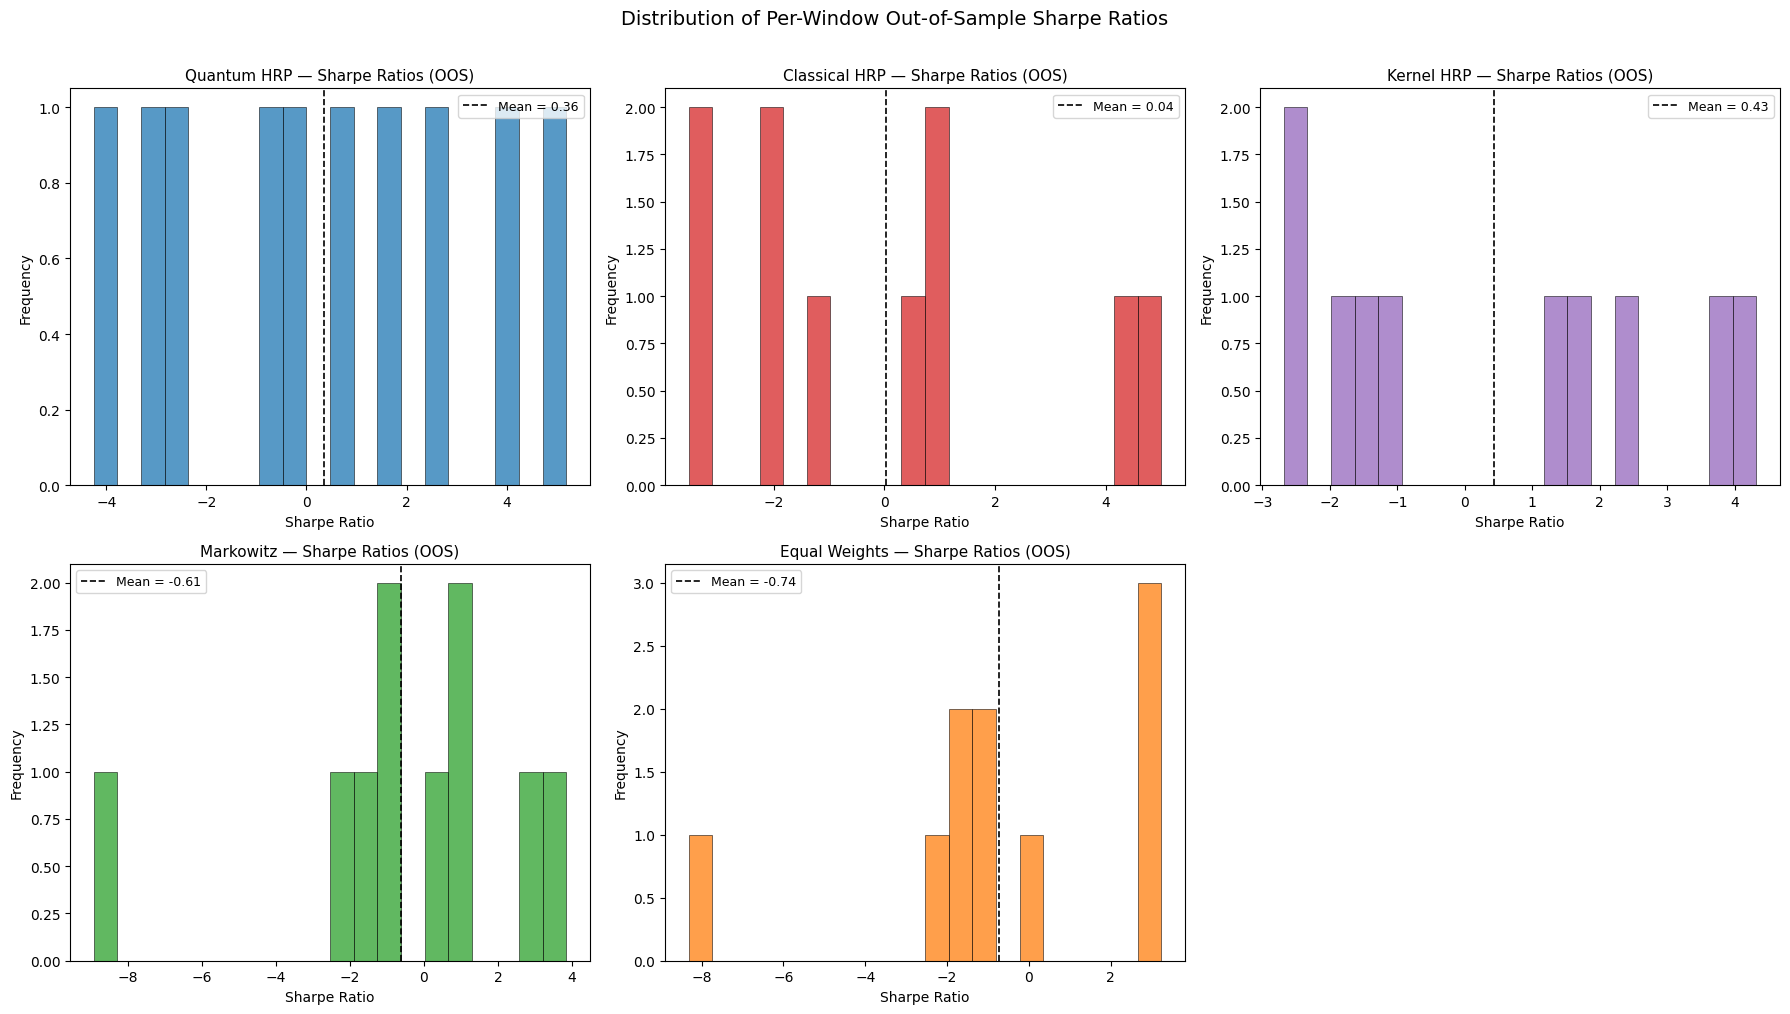

In [59]:
# ══════════════════════════════════════════════════════════════════════════
# Histograms of per-window Sharpe ratios (Figure 5 from the paper)
# ══════════════════════════════════════════════════════════════════════════
colors = {
    "Quantum HRP":  "tab:blue",
    "Classical HRP": "tab:red",
    "Kernel HRP":   "tab:purple",
    "Markowitz":    "tab:green",
    "Equal Weights": "tab:orange",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, m in enumerate(METHODS):
    ax = axes_flat[idx]
    sr_arr = np.array(results[m]["sr"])
    ax.hist(sr_arr, bins=20, color=colors[m], alpha=0.75, edgecolor="black", linewidth=0.5)
    ax.axvline(np.mean(sr_arr), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean = {np.mean(sr_arr):.2f}")
    ax.set_title(f"{m} — Sharpe Ratios (OOS)", fontsize=11)
    ax.set_xlabel("Sharpe Ratio")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

# Turn off the last (unused) subplot
axes_flat[-1].set_visible(False)

plt.suptitle("Distribution of Per-Window Out-of-Sample Sharpe Ratios", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table1-sharpe-histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

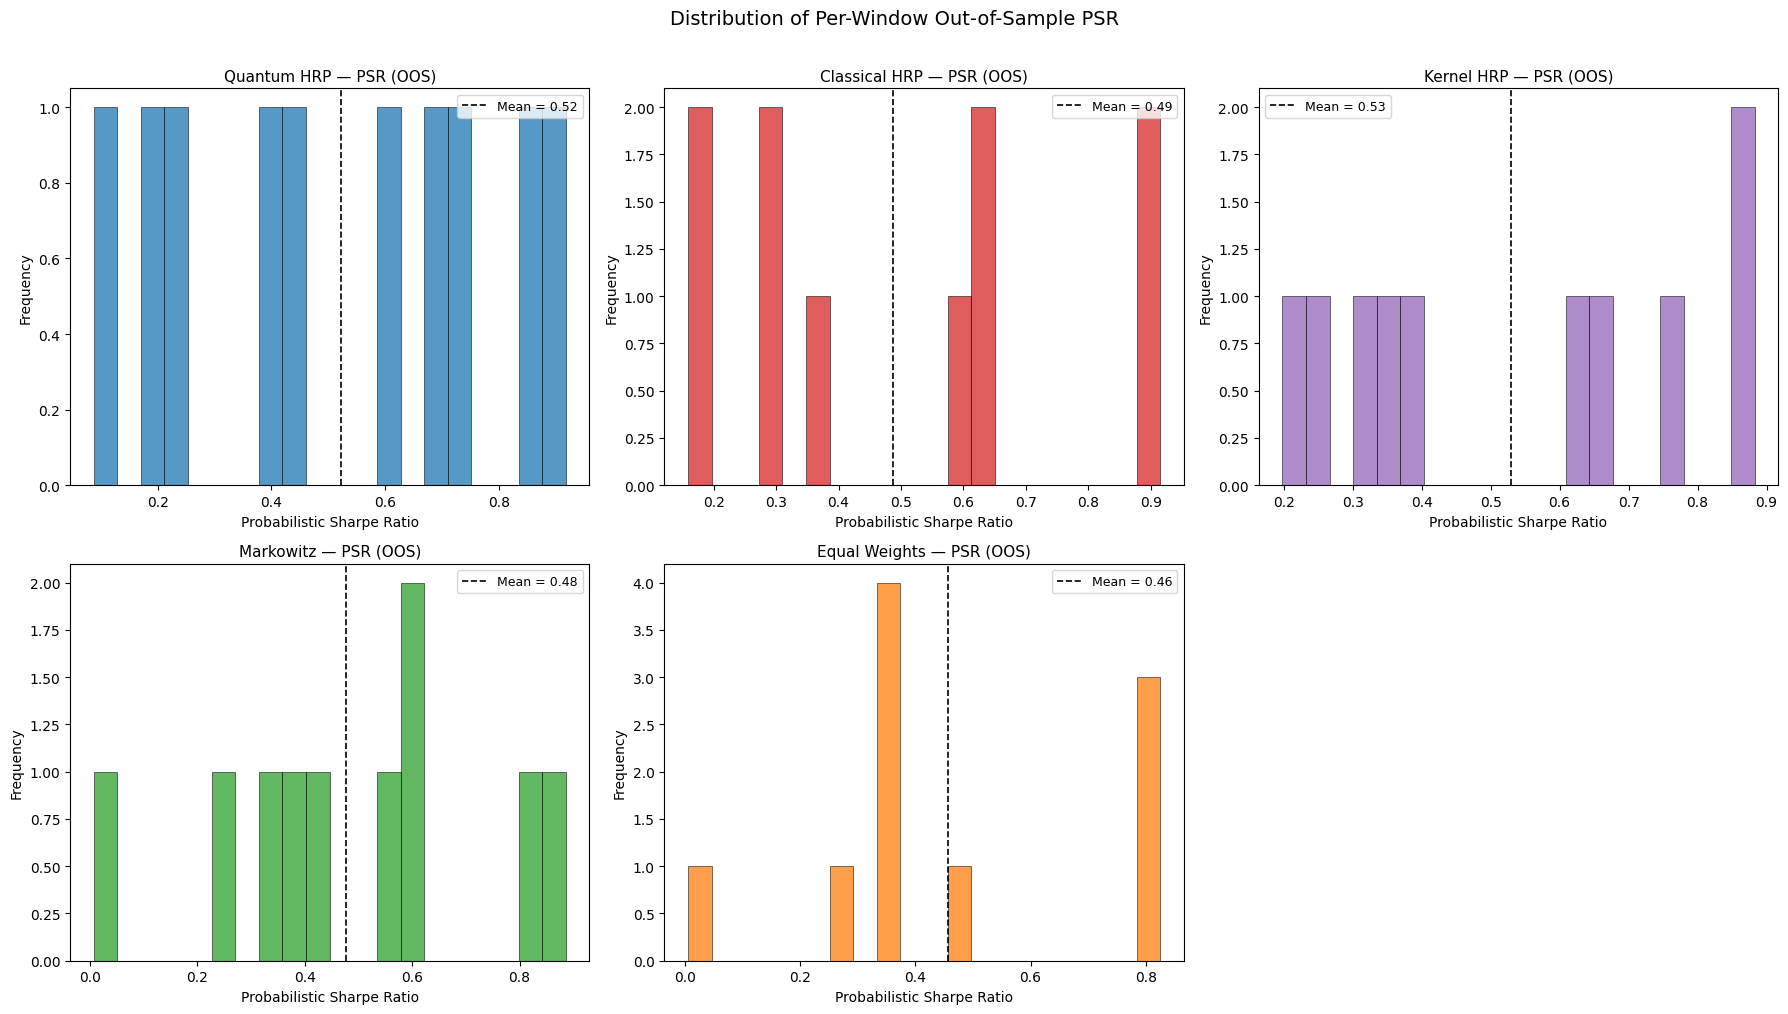

In [60]:
# ══════════════════════════════════════════════════════════════════════════
# Histograms of per-window PSR
# ══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, m in enumerate(METHODS):
    ax = axes_flat[idx]
    psr_arr = np.array(results[m]["psr"])
    ax.hist(psr_arr, bins=20, color=colors[m], alpha=0.75, edgecolor="black", linewidth=0.5)
    ax.axvline(np.mean(psr_arr), color="black", linestyle="--", linewidth=1.2,
               label=f"Mean = {np.mean(psr_arr):.2f}")
    ax.set_title(f"{m} — PSR (OOS)", fontsize=11)
    ax.set_xlabel("Probabilistic Sharpe Ratio")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9)

axes_flat[-1].set_visible(False)

plt.suptitle("Distribution of Per-Window Out-of-Sample PSR", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table1-psr-histograms.png"), dpi=300, bbox_inches="tight")
plt.show()

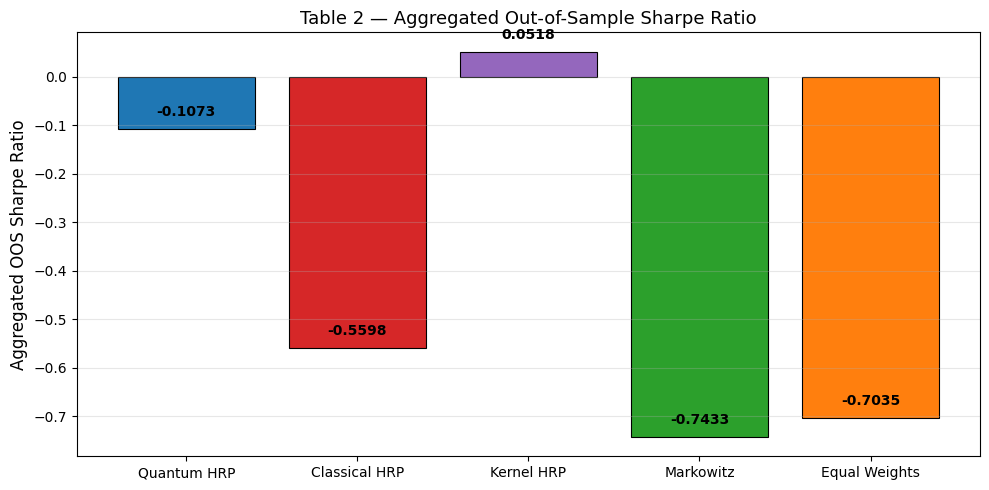

In [61]:
# ══════════════════════════════════════════════════════════════════════════
# Bar chart comparison — Table 2 (Aggregated Sharpe)
# ══════════════════════════════════════════════════════════════════════════
agg_sharpes = {}
for m in METHODS:
    oos_ret = np.array(results[m]["oos_returns"])
    agg_sharpes[m] = sharpe_ratio(oos_ret, rf=RF, annualization_factor=252)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    agg_sharpes.keys(), agg_sharpes.values(),
    color=[colors[m] for m in METHODS],
    edgecolor="black", linewidth=0.8
)
for bar, val in zip(bars, agg_sharpes.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylabel("Aggregated OOS Sharpe Ratio", fontsize=12)
ax.set_title("Table 2 — Aggregated Out-of-Sample Sharpe Ratio", fontsize=13)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "table2-aggregated-sharpe.png"), dpi=300, bbox_inches="tight")
plt.show()